# Vaihe 2: Box-setupien tunnistaminen

Ajaa Box Methodin setup-detektorin kummallekin parille (ETHUSDT, SOLUSDT)
ja tallentaa löytyneet setupit `data/processed/setups.parquet`-tiedostoon.

## Box Methodin säännöt (lukitut)
1. Boxi: edellisen UTC-päivän high/low, keskiviiva = (high+low)/2
2. Sisäänmeno alapuoliskossa (long): kun close > keskiviiva, sitten ensimmäinen
   vihreä punaisten ketjun jälkeen → kynttilä joka sulkee sen huipun yläpuolelle
3. Sisäänmeno yläpuoliskossa (short): peilikuva yllä olevasta
4. TP = boxin vastakkainen reuna, SL = sisäänmenokynttilän low/high
5. Expired = päivä loppui ennen TP:tä tai SL:ää
6. Useita setupia per päivä sallittu, ei päällekkäisiä kauppoja

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import pandas as pd

# Lisää projektin juuri Python-polkuun
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.box_method import find_all_setups

raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

print(f"Raw-data: {raw_dir}")
print(f"Processed-data: {processed_dir}")

Raw-data: /Users/sbanbe/Documents/projektit/boxmethod/data/raw
Processed-data: /Users/sbanbe/Documents/projektit/boxmethod/data/processed


In [2]:
SYMBOLS = ["ETHUSDT", "SOLUSDT"]

# Lataa 5min ja 1d data molemmille pareille
data = {}
for symbol in SYMBOLS:
    df_5m = pd.read_parquet(raw_dir / f"{symbol}_5m.parquet")
    df_1d = pd.read_parquet(raw_dir / f"{symbol}_1d.parquet")
    data[symbol] = {"5m": df_5m, "1d": df_1d}
    print(f"{symbol}: 5m={len(df_5m):,} riviä, 1d={len(df_1d):,} riviä")

ETHUSDT: 5m=247,105 riviä, 1d=859 riviä
SOLUSDT: 5m=247,105 riviä, 1d=859 riviä


In [21]:
all_setups = []

for symbol in SYMBOLS:
    print(f"\nEtsitään setupeja: {symbol}...")
    setups_df = find_all_setups(
        df_5m=data[symbol]["5m"],
        df_1d=data[symbol]["1d"],
        symbol=symbol,
    )
    print(f"  Löytyi {len(setups_df)} setupia")
    all_setups.append(setups_df)

# Yhdistä molemmat parit
setups = pd.concat(all_setups, ignore_index=True)
print(f"\nYhteensä: {len(setups)} setupia")


Etsitään setupeja: ETHUSDT...
  Löytyi 4016 setupia

Etsitään setupeja: SOLUSDT...
  Löytyi 4265 setupia

Yhteensä: 8281 setupia


In [22]:
print("Setupit per pari:")
print(setups.groupby("symbol").size())
print("\nSetupit per suunta:")
print(setups.groupby(["symbol", "direction"]).size())
print("\nLopputulokset:")
print(setups.groupby("outcome").size())
print("\nLopputulokset per pari:")
print(setups.groupby(["symbol", "outcome"]).size().unstack(fill_value=0))

Setupit per pari:
symbol
ETHUSDT    4016
SOLUSDT    4265
dtype: int64

Setupit per suunta:
symbol   direction
ETHUSDT  long         1941
         short        2075
SOLUSDT  long         2150
         short        2115
dtype: int64

Lopputulokset:
outcome
expired    1640
sl         6172
tp          469
dtype: int64

Lopputulokset per pari:
outcome  expired    sl   tp
symbol                     
ETHUSDT      832  2926  258
SOLUSDT      808  3246  211


In [24]:
# Vain ne setupit, jotka olivat selvästi voittoja tai tappioita (ei expired)
labeled = setups[setups["label"].notna()].copy()
labeled["label"] = labeled["label"].astype(int)

print(f"Labeled-setupit (ei expired): {len(labeled)}")
print(f"Voittoja (label=1): {(labeled['label'] == 1).sum()} "
      f"({(labeled['label'] == 1).mean() * 100:.1f}%)")
print(f"Tappioita (label=0): {(labeled['label'] == 0).sum()} "
      f"({(labeled['label'] == 0).mean() * 100:.1f}%)")

print("\nKeskimääräinen risk/reward-suhde:")
print(setups.groupby("direction")["risk_reward_ratio"].describe()[["mean", "50%", "min", "max"]])

Labeled-setupit (ei expired): 6641
Voittoja (label=1): 469 (7.1%)
Tappioita (label=0): 6172 (92.9%)

Keskimääräinen risk/reward-suhde:
               mean       50%       min       max
direction                                        
long       8.707598  7.808195  0.546507  36.32158
short      9.797387  8.727911  0.421979  59.49085


In [25]:
setups["date_only"] = pd.to_datetime(setups["date"]).dt.date
setups_per_day = setups.groupby(["symbol", "date_only"]).size()

print("Setupia per päivä (jakauma per pari):")
print(setups_per_day.groupby(level=0).describe()[["mean", "50%", "min", "max"]])

print(f"\nPäiviä joina ei yhtään setupia (ETHUSDT):")
all_dates = pd.date_range(setups["date_only"].min(), setups["date_only"].max())
eth_dates = setups[setups["symbol"] == "ETHUSDT"]["date_only"].unique()
empty_days_eth = len(all_dates) - len(eth_dates)
print(f"  {empty_days_eth} / {len(all_dates)} päivää")

Setupia per päivä (jakauma per pari):
             mean  50%  min   max
symbol                           
ETHUSDT  4.686114  4.0  1.0  13.0
SOLUSDT  4.976663  5.0  1.0  16.0

Päiviä joina ei yhtään setupia (ETHUSDT):
  0 / 857 päivää


=== 3 VOITTOA ===


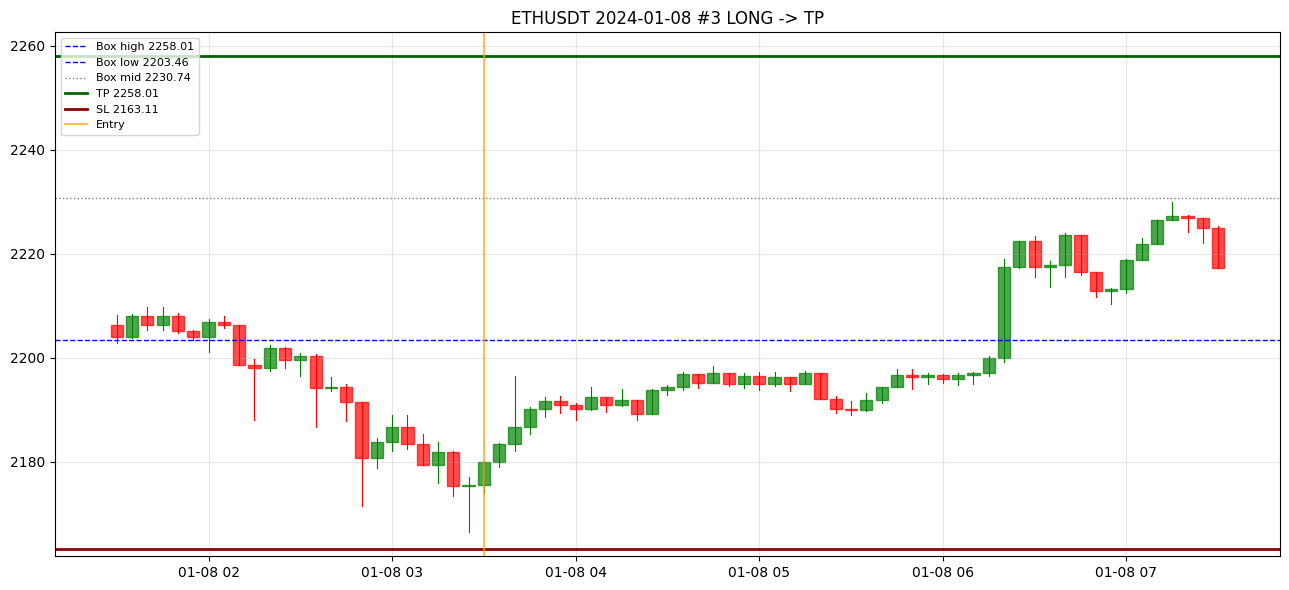

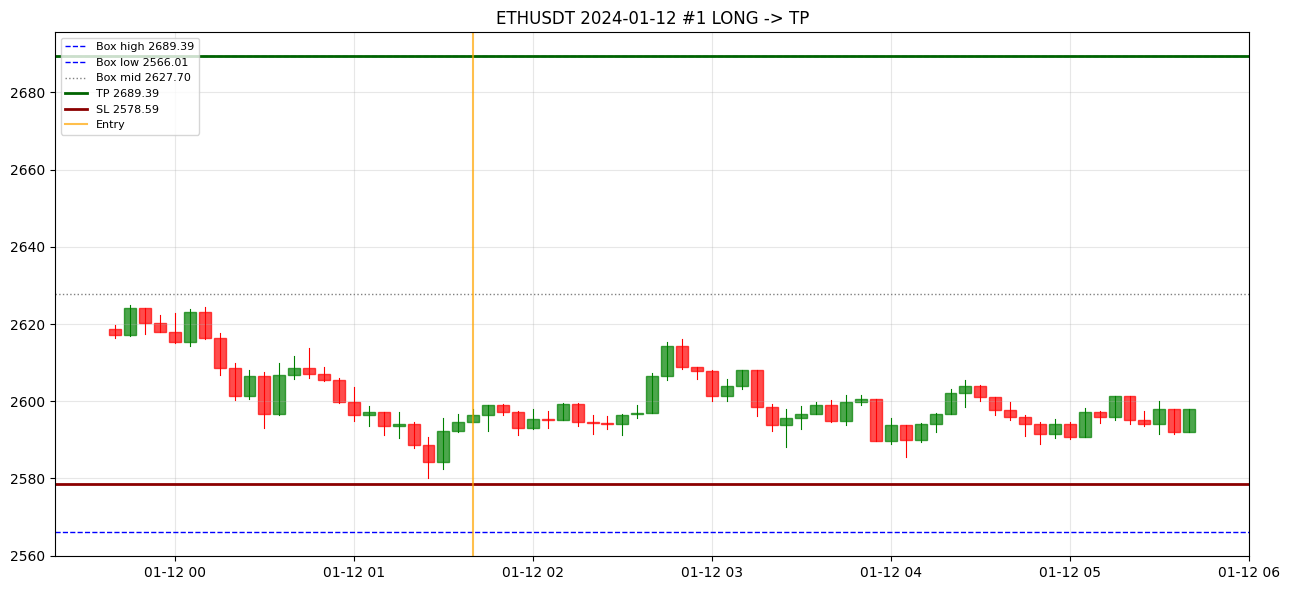

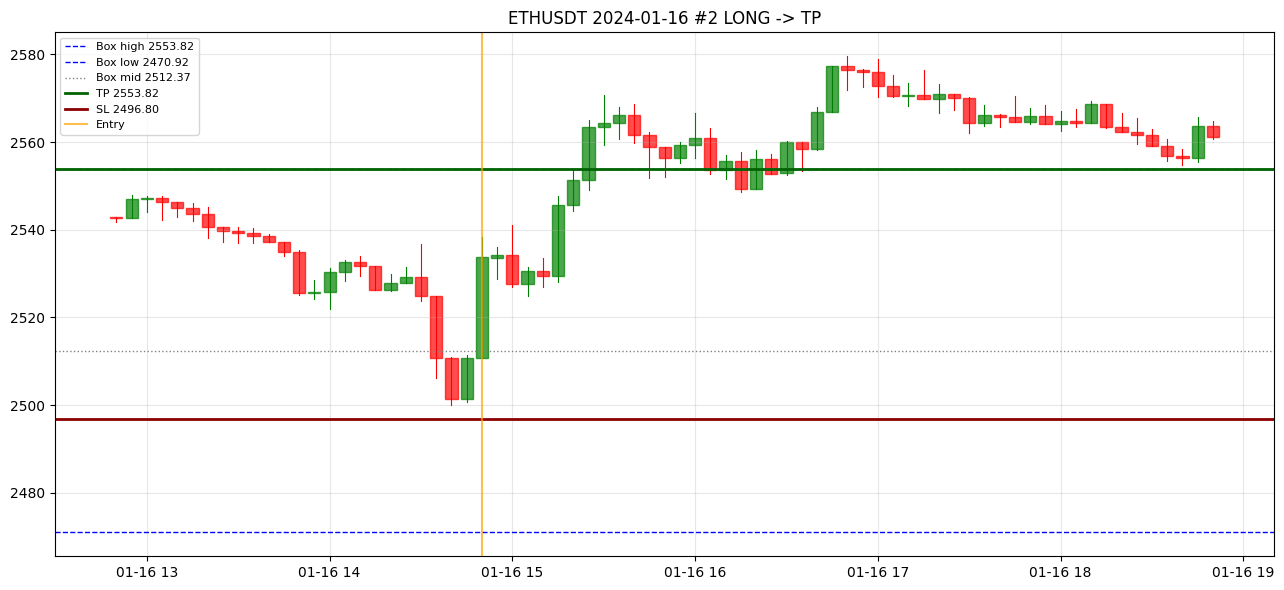


=== 3 TAPPIOTA ===


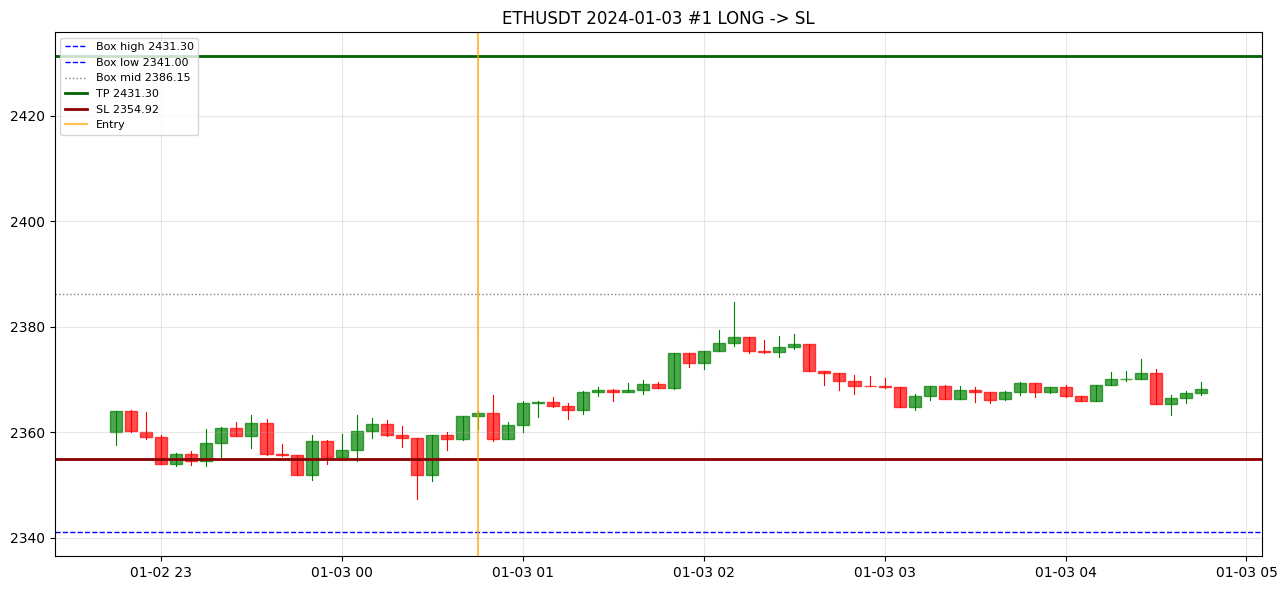

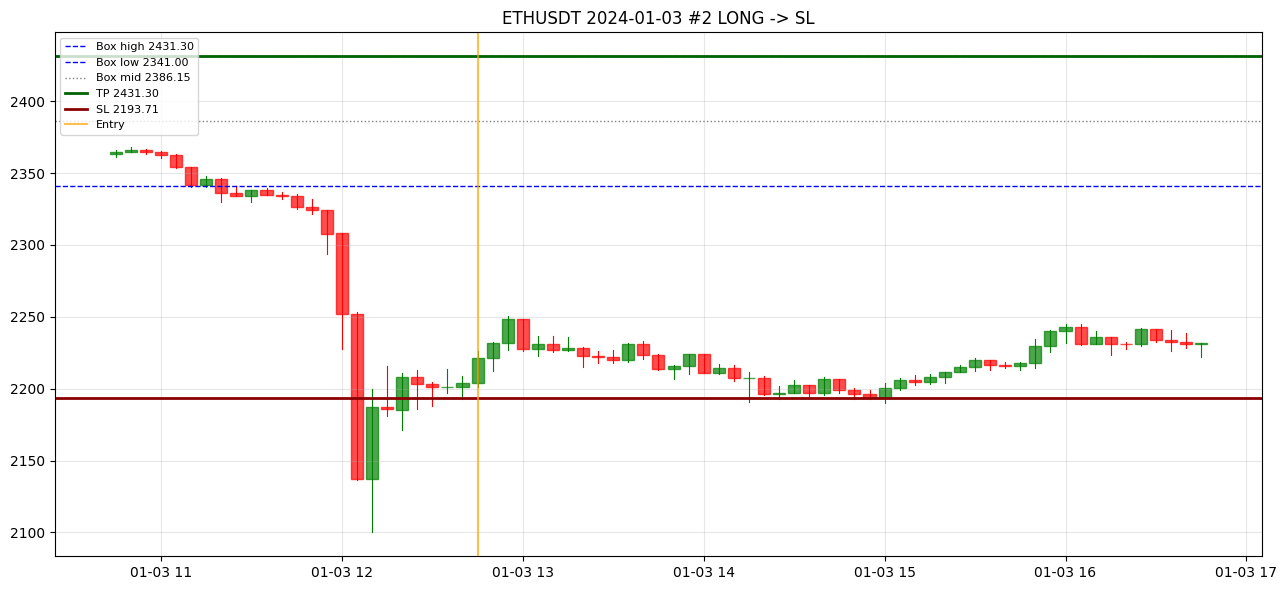

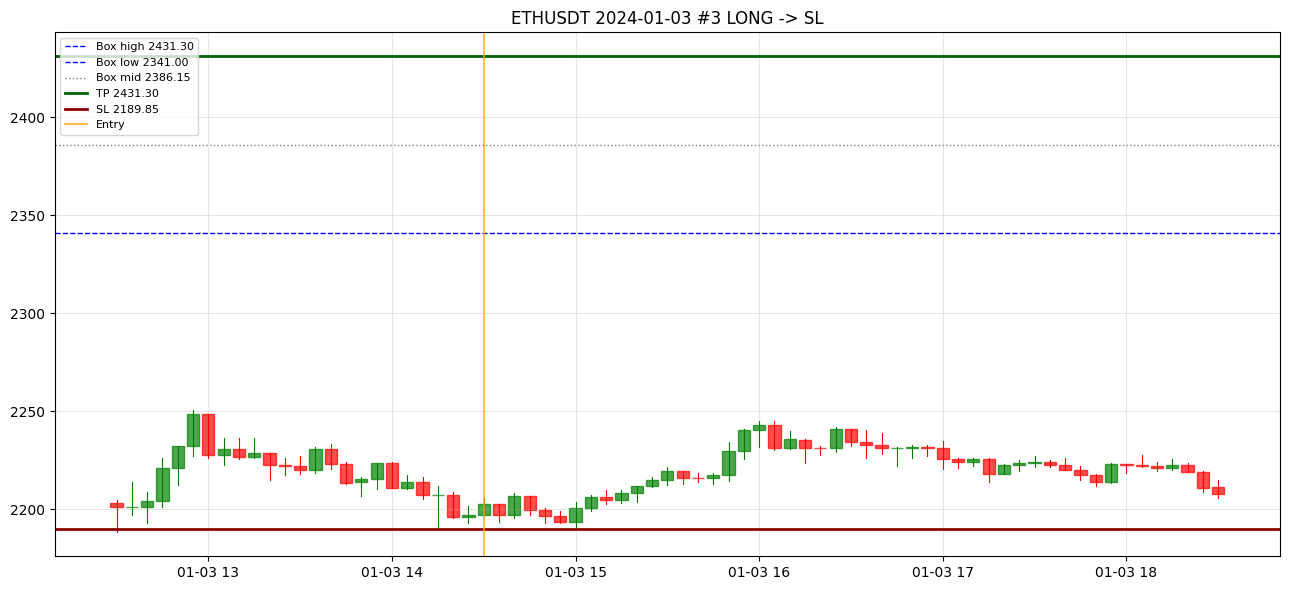

In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_setup(setup_row, df_5m, df_1d, hours_before=2, hours_after=4):
    """Piirtää yhden setupin: 5min-kynttilät, boxin reunat ja tasot."""
    entry_time = pd.Timestamp(setup_row["entry_time"])
    box_high = setup_row["box_high"]
    box_low = setup_row["box_low"]
    box_mid = setup_row["box_mid"]
    sl = setup_row["stop_loss"]
    tp = setup_row["take_profit"]
    direction = setup_row["direction"]
    outcome = setup_row["outcome"]

    start = entry_time - pd.Timedelta(hours=hours_before)
    end = entry_time + pd.Timedelta(hours=hours_after)
    window = df_5m.loc[(df_5m.index >= start) & (df_5m.index <= end)].copy()

    fig, ax = plt.subplots(figsize=(13, 6))

    for ts, c in window.iterrows():
        color = "green" if c["close"] >= c["open"] else "red"
        ax.plot([ts, ts], [c["low"], c["high"]], color=color, linewidth=0.8)
        body_low = min(c["open"], c["close"])
        body_high = max(c["open"], c["close"])
        rect = patches.Rectangle(
            (ts - pd.Timedelta(minutes=2), body_low),
            pd.Timedelta(minutes=4),
            body_high - body_low,
            color=color, alpha=0.7
        )
        ax.add_patch(rect)

    ax.axhline(box_high, color="blue", linestyle="--", linewidth=1, label=f"Box high {box_high:.2f}")
    ax.axhline(box_low, color="blue", linestyle="--", linewidth=1, label=f"Box low {box_low:.2f}")
    ax.axhline(box_mid, color="gray", linestyle=":", linewidth=1, label=f"Box mid {box_mid:.2f}")
    ax.axhline(tp, color="darkgreen", linewidth=2, label=f"TP {tp:.2f}")
    ax.axhline(sl, color="darkred", linewidth=2, label=f"SL {sl:.2f}")
    ax.axvline(entry_time, color="orange", linewidth=1.5, alpha=0.7, label="Entry")

    title = f"{setup_row['symbol']} {setup_row['date'].date()} #{setup_row['setup_index_in_day']} {direction.upper()} -> {outcome.upper()}"
    ax.set_title(title)
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Suodatetaan eri ehtoja erikseen, vältetään pitkä yksirivinen rakenne
eth = setups[setups["symbol"] == "ETHUSDT"]
eth_long = eth[eth["direction"] == "long"]

sample_wins = eth_long[eth_long["outcome"] == "tp"].head(3)
sample_losses = eth_long[eth_long["outcome"] == "sl"].head(3)

print(f"=== {len(sample_wins)} VOITTOA ===")
for _, row in sample_wins.iterrows():
    plot_setup(row, data["ETHUSDT"]["5m"], data["ETHUSDT"]["1d"])

print(f"\n=== {len(sample_losses)} TAPPIOTA ===")
for _, row in sample_losses.iterrows():
    plot_setup(row, data["ETHUSDT"]["5m"], data["ETHUSDT"]["1d"])

In [ ]:
output_path = processed_dir / "setups.parquet"
setups.to_parquet(output_path, engine="pyarrow", compression="snappy")

size_kb = output_path.stat().st_size / 1024
print(f"Tallennettu: {output_path}")
print(f"  {len(setups)} setupia, {size_kb:.1f} KB")

In [ ]:
# 5 ensimmäistä long-setupia
print("Esimerkkejä long-setupeista:")
display(setups[setups["direction"] == "long"].head().drop(
    columns=["box_high", "box_low", "box_mid", "outcome_time"]
))

In [27]:
# Vertaa: kaikki setupit vs. vain ensimmäinen per päivä

print("=" * 60)
print("KAIKKI SETUPIT")
print("=" * 60)
labeled_all = setups[setups["label"].notna()].copy()
labeled_all["label"] = labeled_all["label"].astype(int)
print(f"Setupia: {len(labeled_all)}")
print(f"Voitto-%: {labeled_all['label'].mean() * 100:.1f}%")

print("\n" + "=" * 60)
print("VAIN ENSIMMÄINEN SETUP PER PÄIVÄ PER PARI")
print("=" * 60)
first_only = setups[setups["setup_index_in_day"] == 1]
first_labeled = first_only[first_only["label"].notna()].copy()
first_labeled["label"] = first_labeled["label"].astype(int)
print(f"Setupia: {len(first_labeled)}")
print(f"Voitto-%: {first_labeled['label'].mean() * 100:.1f}%")

print("\n" + "=" * 60)
print("VOITTO-% SETUPIN INDEKSIN MUKAAN PÄIVÄN SISÄLLÄ")
print("=" * 60)
for idx in range(1, 11):
    subset = setups[setups["setup_index_in_day"] == idx]
    subset_labeled = subset[subset["label"].notna()]
    if len(subset_labeled) > 30:
        wr = subset_labeled["label"].astype(int).mean() * 100
        print(f"Setup #{idx}: n={len(subset_labeled):4d}, voitto-%={wr:5.1f}%")

KAIKKI SETUPIT
Setupia: 6641
Voitto-%: 7.1%

VAIN ENSIMMÄINEN SETUP PER PÄIVÄ PER PARI
Setupia: 1610
Voitto-%: 11.0%

VOITTO-% SETUPIN INDEKSIN MUKAAN PÄIVÄN SISÄLLÄ
Setup #1: n=1610, voitto-%= 11.0%
Setup #2: n=1403, voitto-%=  9.2%
Setup #3: n=1152, voitto-%=  6.2%
Setup #4: n= 882, voitto-%=  6.3%
Setup #5: n= 617, voitto-%=  2.9%
Setup #6: n= 412, voitto-%=  2.4%
Setup #7: n= 253, voitto-%=  2.0%
Setup #8: n= 154, voitto-%=  1.3%
Setup #9: n=  78, voitto-%=  1.3%
Setup #10: n=  40, voitto-%=  0.0%


In [28]:
# Tallenna setupit Parquet-tiedostoon
output_path = processed_dir / "setups.parquet"
setups.to_parquet(output_path, engine="pyarrow", compression="snappy")

size_kb = output_path.stat().st_size / 1024
print(f"Tallennettu: {output_path}")
print(f"  {len(setups)} setupia, {size_kb:.1f} KB")

Tallennettu: /Users/sbanbe/Documents/projektit/boxmethod/data/processed/setups.parquet
  8281 setupia, 480.0 KB
